# 01 — Auditoria, análise exploratória e drift D0 → D1

Billboard Hot 100: prever se a música melhora de posição na semana seguinte. Este notebook usa somente D0 e D1; D2 permanece reservado. Pré-requisito: `python baixar_dados.py` e `python preparar_desenvolvimento.py`.

In [1]:
from pathlib import Path
import os
import sys
raiz = Path.cwd()
if not (raiz / 'analisar_dados_drift.py').exists():
    raiz = raiz.parent
assert (raiz / 'analisar_dados_drift.py').exists(), 'Abra o notebook dentro do repositorio.'
os.chdir(raiz)
if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))
import pandas as pd
import json
from IPython.display import display, Markdown, Image


## Fonte, integridade e períodos

Os hashes da versão 175 são conferidos antes da análise. Os scripts são a fonte dos cálculos; o notebook os executa e apresenta os artefatos. Não há ajuste de modelos nesta análise.

conjunto  linhas  semanas     inicio        fim  proporcao_alvo  ausentes  duplicatas
      D0   42800      428 2013-01-02 2021-03-10        0.361612         0           0
      D1   14200      142 2021-03-24 2023-12-06        0.313028         0           0
      atributo      psi       ks
  digital_rank 0.093723 0.141845
    album_rank 0.083305 0.085289
distancia_pico 0.076586 0.119924
   variacao_1s 0.075151 0.070759
      peak_pos 0.045803 0.102885


,conjunto,linhas,semanas,inicio,fim,proporcao_alvo,ausentes,duplicatas
0,D0,42800,428,2013-01-02,2021-03-10,0.361612,0,0
1,D1,14200,142,2021-03-24,2023-12-06,0.313028,0,0


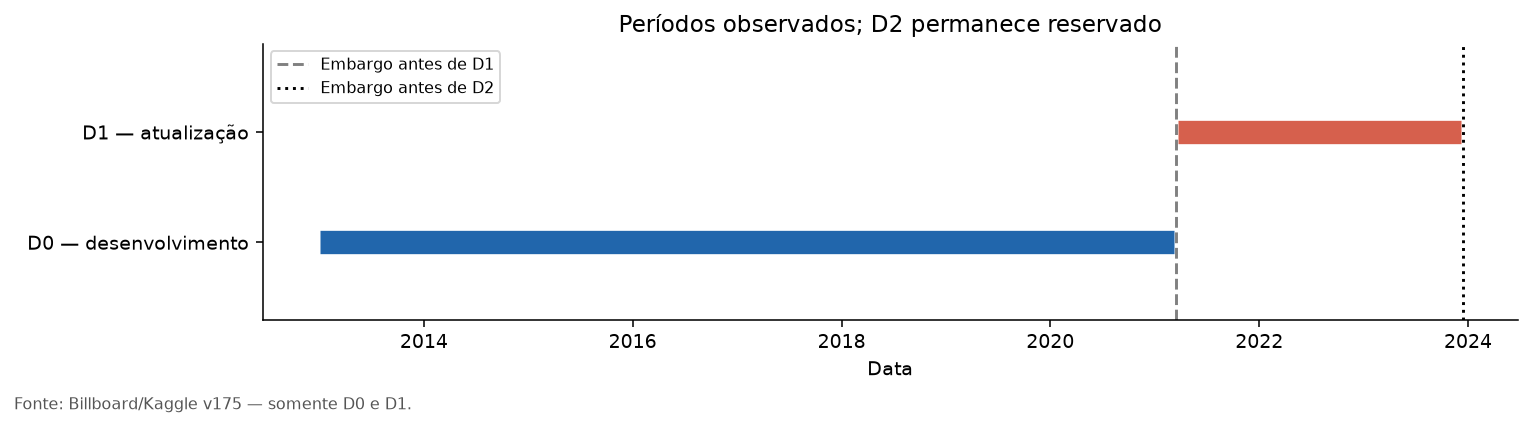

In [2]:
from analisar_dados_drift import executar, carregar_desenvolvimento
resumo, drift = executar()
dados, hashes = carregar_desenvolvimento()
display(resumo)
display(Image(filename='resultados/aed_drift/figuras/linha_tempo.png'))

## Definição do alvo

Classe 1: a posição numérica diminui em t+1. Classe 0: posição igual, maior ou saída do ranking. Um exemplo hipotético: passar de 20 para 15 é classe 1; de 20 para 25 é classe 0. As observações abaixo são exemplos reais de D0, com os rótulos já auditados.

In [3]:
display(dados['D0'][['date','title','artist','rank','alvo']].head(10))

,date,title,artist,rank,alvo
0,2013-01-02,Locked Out Of Heaven,Bruno Mars,1,0
1,2013-01-02,Diamonds,Rihanna,2,0
2,2013-01-02,Ho Hey,The Lumineers,3,0
3,2013-01-02,I Knew You Were Trouble.,Taylor Swift,4,1
4,2013-01-02,Beauty And A Beat,Justin Bieber Featuring Nicki Minaj,5,0
5,2013-01-02,Die Young,Ke$ha,6,0
6,2013-01-02,One More Night,Maroon 5,7,0
7,2013-01-02,I Cry,Flo Rida,8,0
8,2013-01-02,Home,Phillip Phillips,9,0
9,2013-01-02,Thrift Shop,Macklemore & Ryan Lewis Featuring Wanz,10,0


## Balanceamento e evolução temporal

A proporção do alvo é apresentada por período e em média móvel de 13 semanas. Essa suavização é apenas visual e não participa do treinamento.

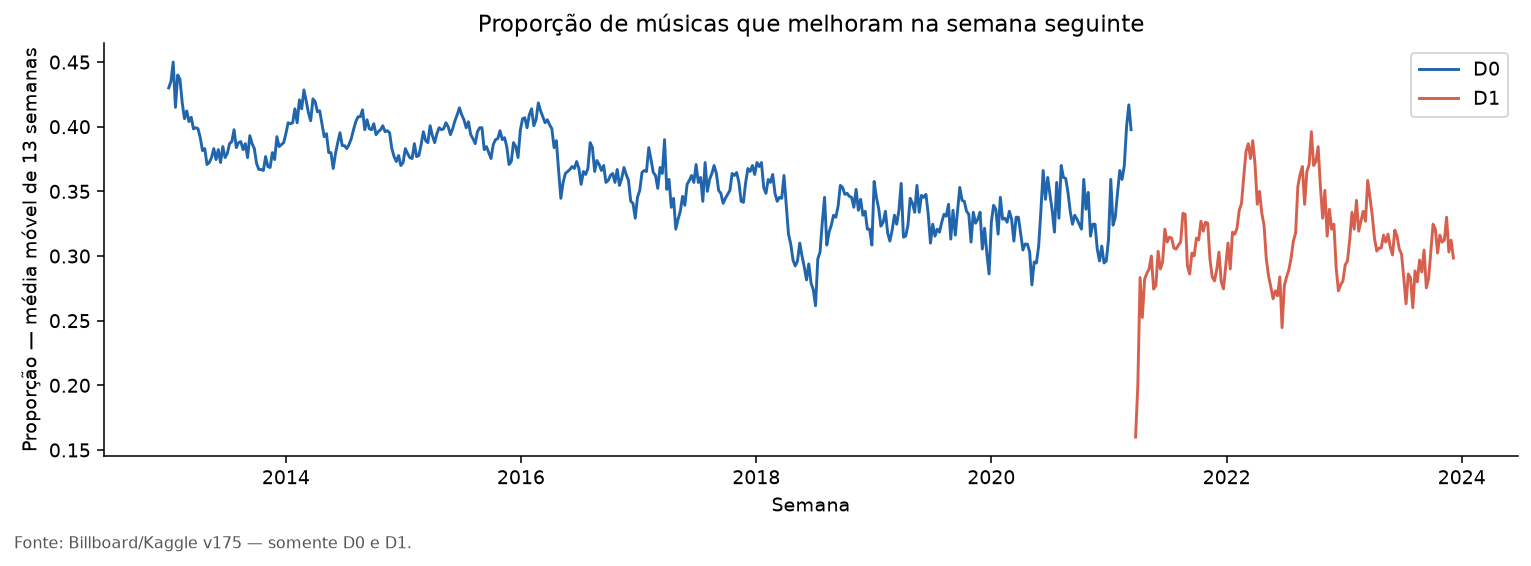

In [4]:
display(Image(filename='resultados/aed_drift/figuras/alvo_temporal.png'))

## Distribuições, cobertura e ausências

As CDFs mostram a distribuição completa, sem remover caudas. Não há nulos nos atributos processados; ausências dos rankings usam sentinelas 101/51/201 e indicadores de presença. `estreia` marca início de passagem, incluindo retornos após hiatos superiores a 28 dias; `reentrada` é o subconjunto de inícios de passagem de músicas já vistas.

,count,mean,std,min,25%,50%,75%,max
rank,42800.0,50.500000,28.866407,1.0,25.75,50.5,75.25,100.0
rank_lag1,42800.0,53.078411,31.228474,1.0,26.00,53.0,80.00,101.0
rank_lag2,42800.0,55.426262,32.833155,1.0,26.00,55.0,86.00,101.0
variacao_1s,42800.0,2.578411,16.076909,-80.0,-4.00,0.0,5.00,100.0
peak_pos,42800.0,38.382290,29.060237,1.0,11.00,36.0,62.00,100.0
distancia_pico,42800.0,12.117710,16.625682,0.0,0.00,4.0,19.00,99.0
semanas_na_parada,42800.0,11.950047,10.296290,1.0,4.00,10.0,17.00,85.0
hiato_semanas,42800.0,0.023154,0.211696,0.0,0.00,0.0,0.00,3.0
estreia,42800.0,0.101822,0.302418,0.0,0.00,0.0,0.00,1.0
reentrada,42800.0,0.010981,0.104216,0.0,0.00,0.0,0.00,1.0


,count,mean,std,min,25%,50%,75%,max
rank,14200.0,50.500000,28.867087,1.0,25.75,50.5,75.25,100.0
rank_lag1,14200.0,54.208380,32.028588,1.0,26.00,53.5,83.00,101.0
rank_lag2,14200.0,57.412606,33.749037,1.0,27.00,57.0,94.00,101.0
variacao_1s,14200.0,3.708380,22.749451,-81.0,-6.00,0.0,6.00,100.0
peak_pos,14200.0,32.853169,27.780443,1.0,8.00,25.0,54.00,100.0
distancia_pico,14200.0,17.646831,20.787506,0.0,0.00,10.0,28.00,98.0
semanas_na_parada,14200.0,11.498099,11.606326,1.0,3.00,8.0,16.00,91.0
hiato_semanas,14200.0,0.028028,0.232999,0.0,0.00,0.0,0.00,3.0
estreia,14200.0,0.138803,0.345753,0.0,0.00,0.0,0.00,1.0
reentrada,14200.0,0.016831,0.128642,0.0,0.00,0.0,0.00,1.0


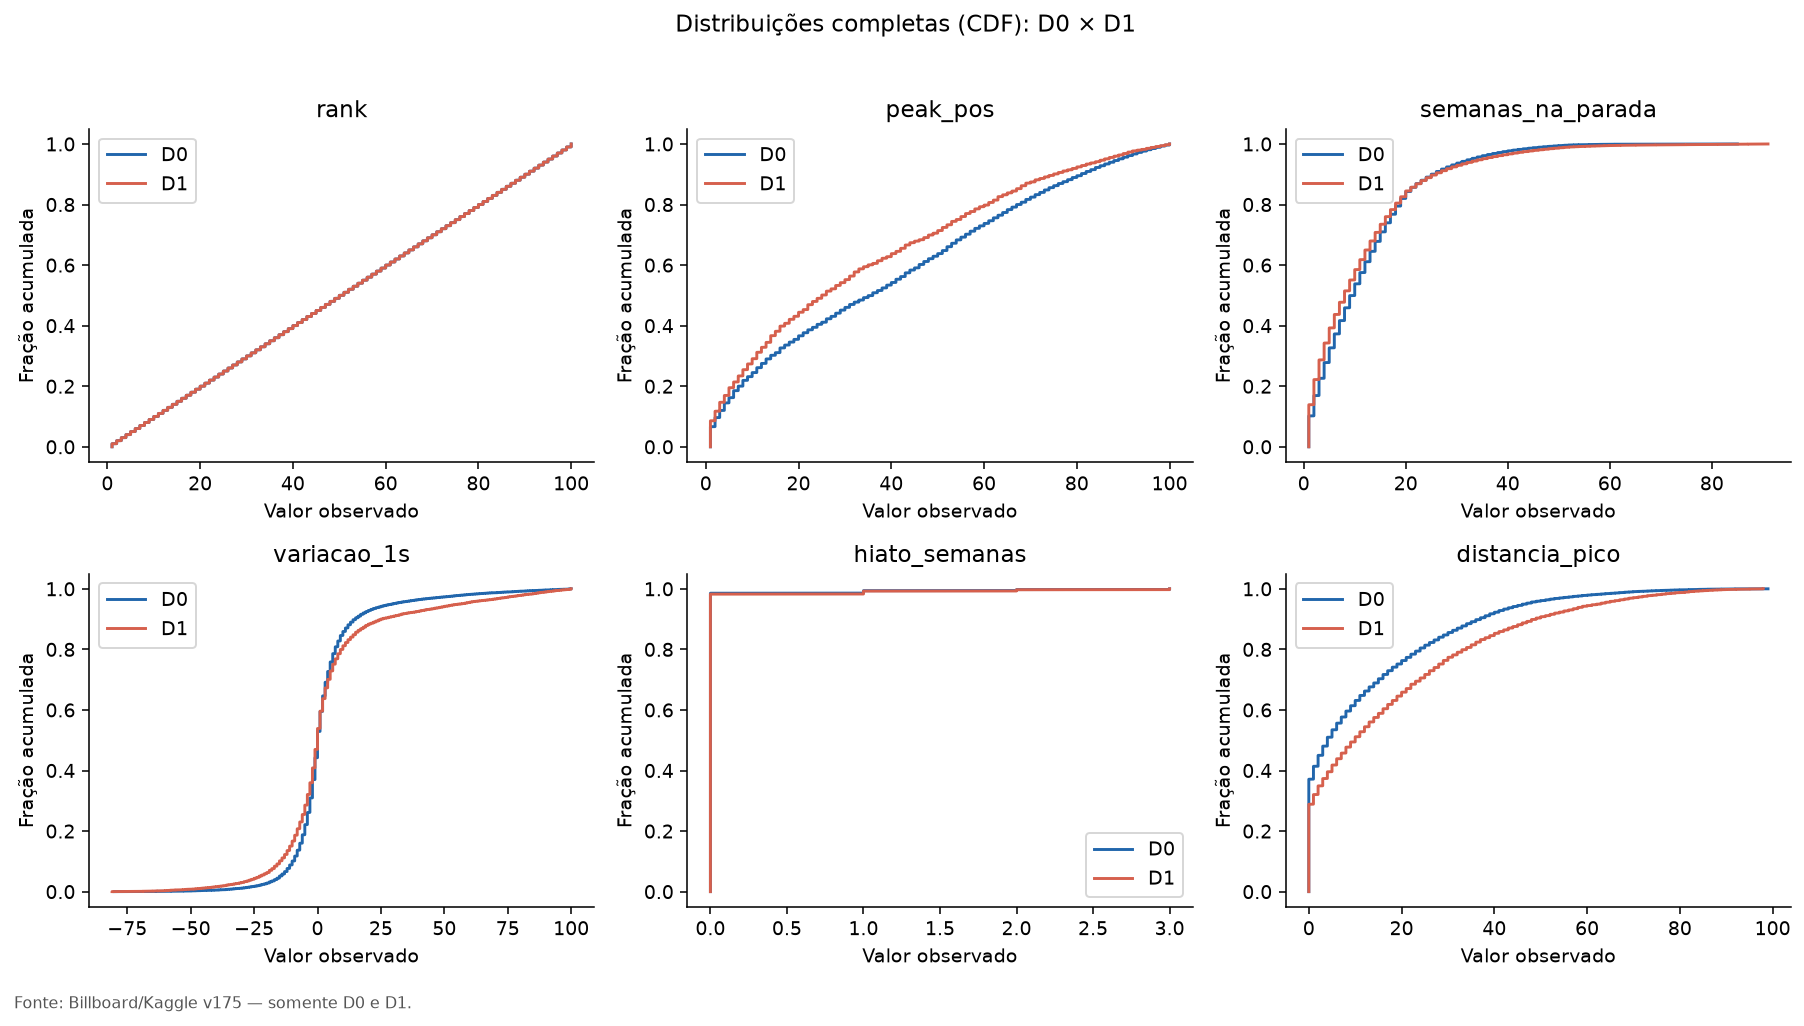

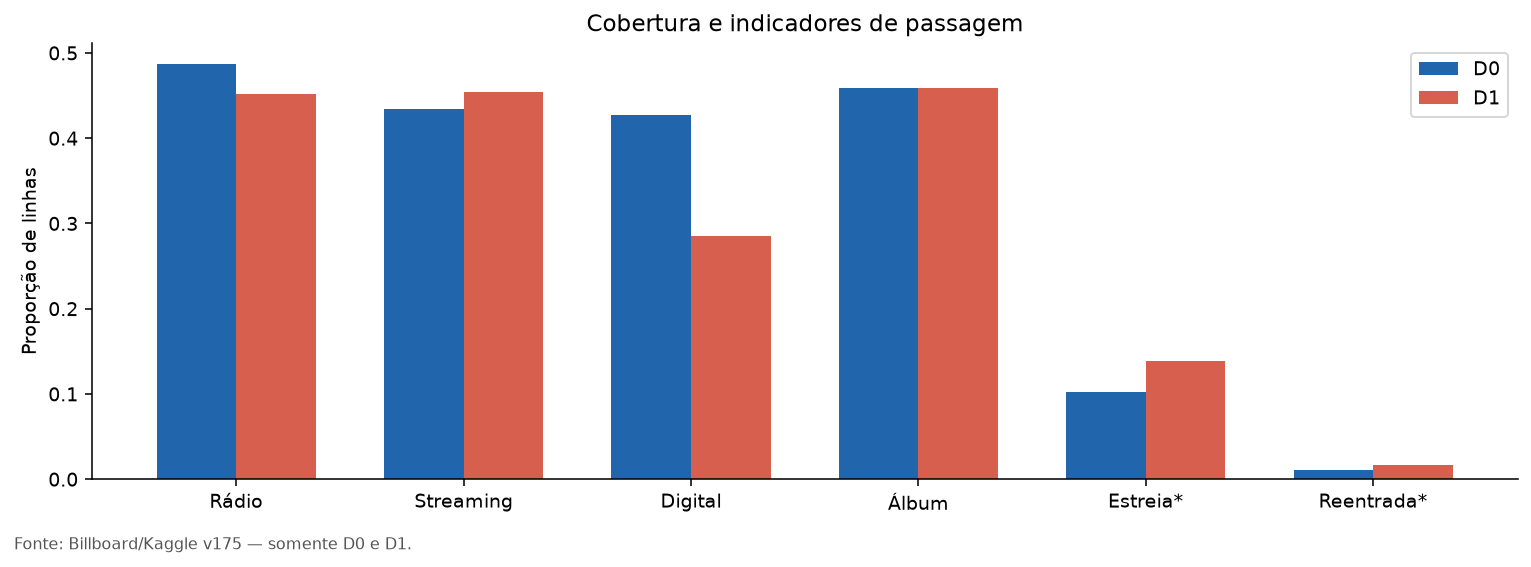

In [5]:
display(pd.read_csv('resultados/aed_drift/descritivas_d0.csv', index_col=0))
display(pd.read_csv('resultados/aed_drift/descritivas_d1.csv', index_col=0))
display(Image(filename='resultados/aed_drift/figuras/distribuicoes.png'))
display(Image(filename='resultados/aed_drift/figuras/cobertura.png'))

## Correlações

Spearman compara associações monotônicas em cada período. Posições, diferenças e indicadores compartilham regras de construção; correlação não demonstra causalidade.

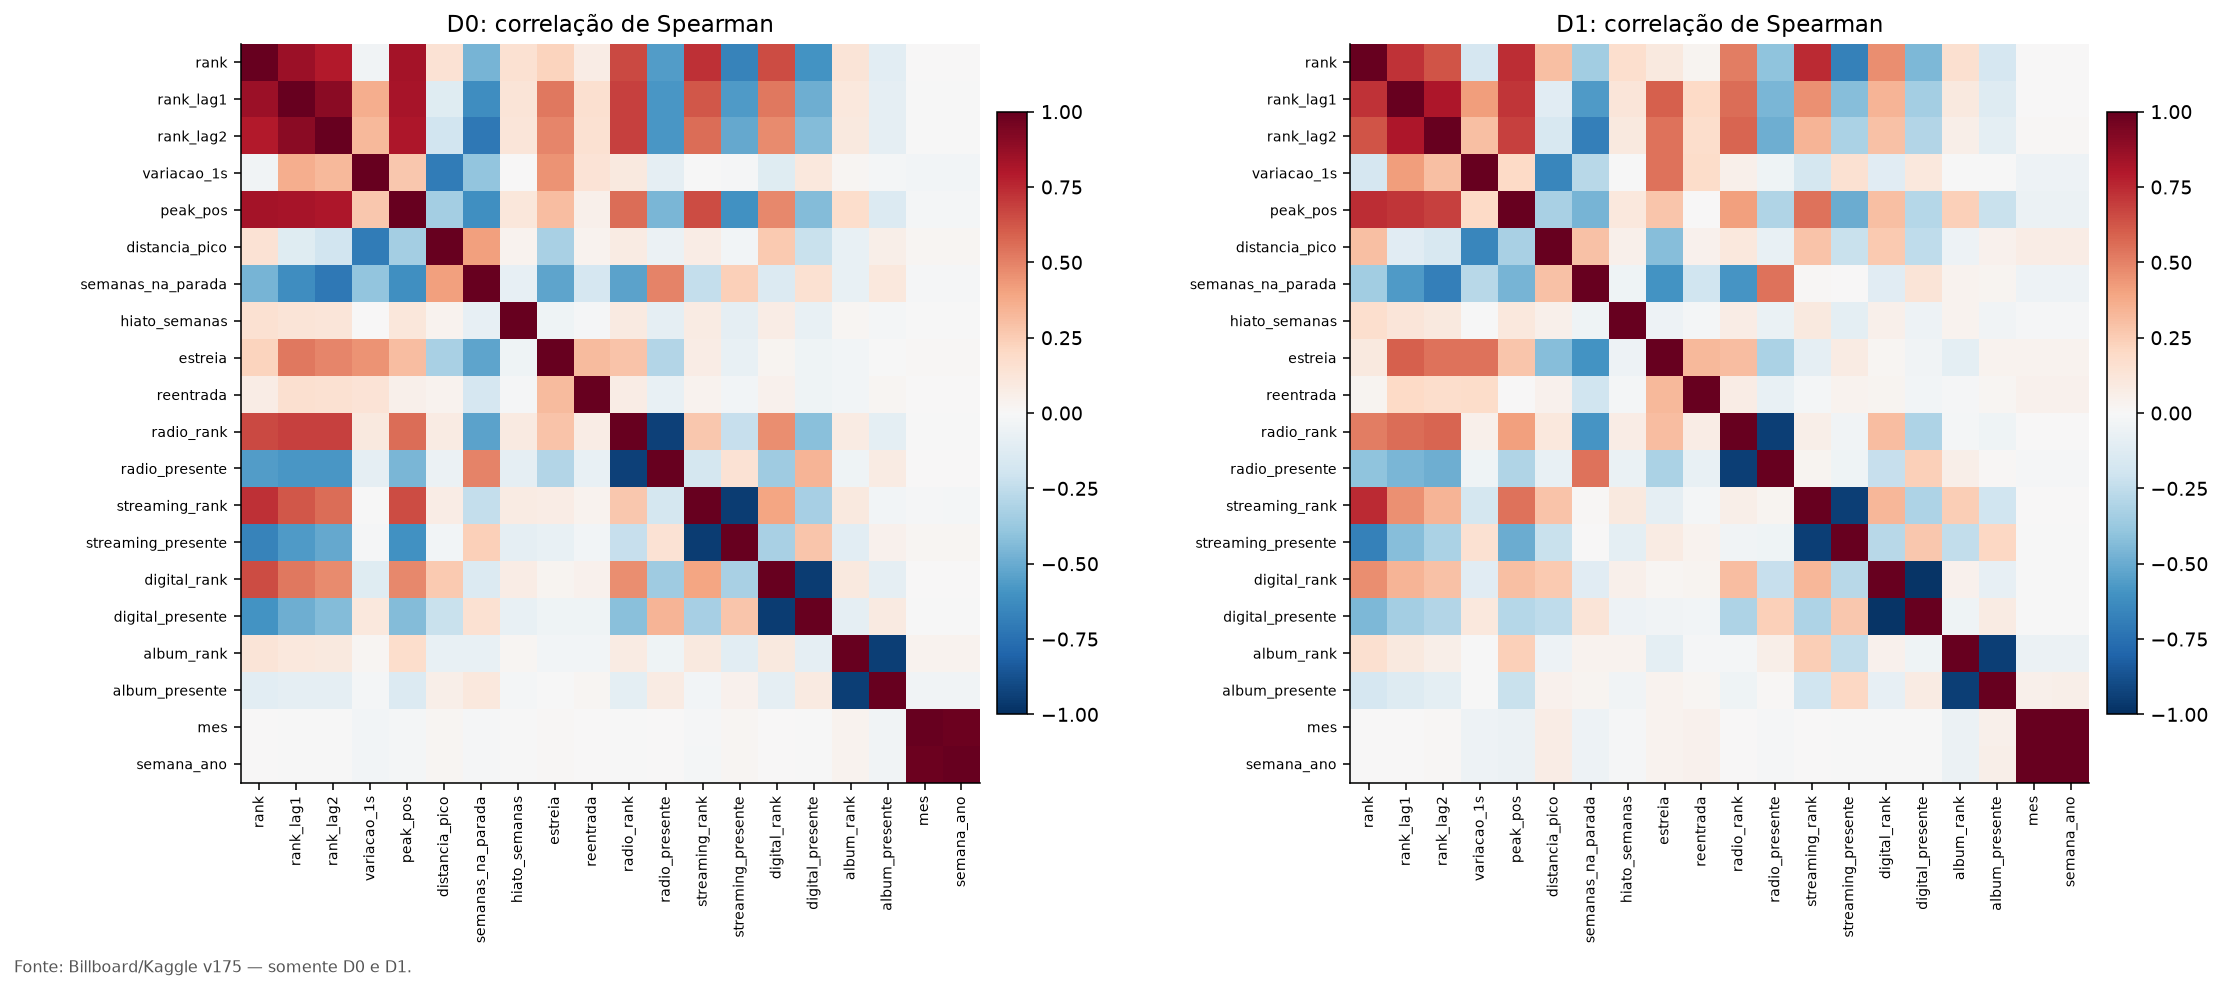

In [6]:
display(Image(filename='resultados/aed_drift/figuras/correlacoes.png'))

## E11 — Drift quantitativo

PSI usa intervalos derivados exclusivamente de D0; KS e Wasserstein medem diferenças numéricas. Jensen–Shannon mede diferenças categóricas. Não usamos p-valores iid porque há dependência entre semanas e repetição de músicas. As medidas são descritivas e não provam concept drift.

,atributo,tipo,ks,psi,wasserstein,wasserstein_por_iqr_d0,js_bits,media_d0,media_d1
10,digital_rank,numerico,1.418448e-01,0.093723,3.304197,0.143661,NaN,39.543902,42.848099
11,album_rank,numerico,8.528893e-02,0.083305,4.377378,0.026691,NaN,131.566916,127.190986
5,distancia_pico,numerico,1.199237e-01,0.076586,5.529214,0.291011,NaN,12.117710,17.646831
3,variacao_1s,numerico,7.075918e-02,0.075151,4.349277,0.483253,NaN,2.578411,3.708380
4,peak_pos,numerico,1.028847e-01,0.045803,5.529121,0.108414,NaN,38.382290,32.853169
6,semanas_na_parada,numerico,6.587567e-02,0.025071,1.117546,0.085965,NaN,11.950047,11.498099
2,rank_lag2,numerico,5.281197e-02,0.020006,1.986344,0.033106,NaN,55.426262,57.412606
1,rank_lag1,numerico,3.698039e-02,0.014388,1.129969,0.020925,NaN,53.078411,54.208380
8,radio_rank,numerico,3.552883e-02,0.007472,0.557852,0.022314,NaN,38.397500,38.955352
9,streaming_rank,numerico,1.963571e-02,0.001920,0.418024,0.017418,NaN,39.205841,38.787817


,atributo,tipo,ks,psi,wasserstein,wasserstein_por_iqr_d0,js_bits,media_d0,media_d1
16,digital_presente,categorico,NaN,NaN,NaN,NaN,1.590339e-02,0.427056,0.285211
19,semana_ano,categorico,NaN,NaN,NaN,NaN,1.030139e-02,26.133178,27.570423
18,mes,categorico,NaN,NaN,NaN,NaN,8.742338e-03,6.397196,6.788732
12,estreia,categorico,NaN,NaN,NaN,NaN,2.338339e-03,0.101822,0.138803
20,alvo,alvo,NaN,NaN,NaN,NaN,1.905490e-03,0.361612,0.313028
14,radio_presente,categorico,NaN,NaN,NaN,NaN,9.141307e-04,0.487360,0.451831
13,reentrada,categorico,NaN,NaN,NaN,NaN,4.533423e-04,0.010981,0.016831
15,streaming_presente,categorico,NaN,NaN,NaN,NaN,2.614621e-04,0.434673,0.453592
17,album_presente,categorico,NaN,NaN,NaN,NaN,4.161162e-11,0.458388,0.458380


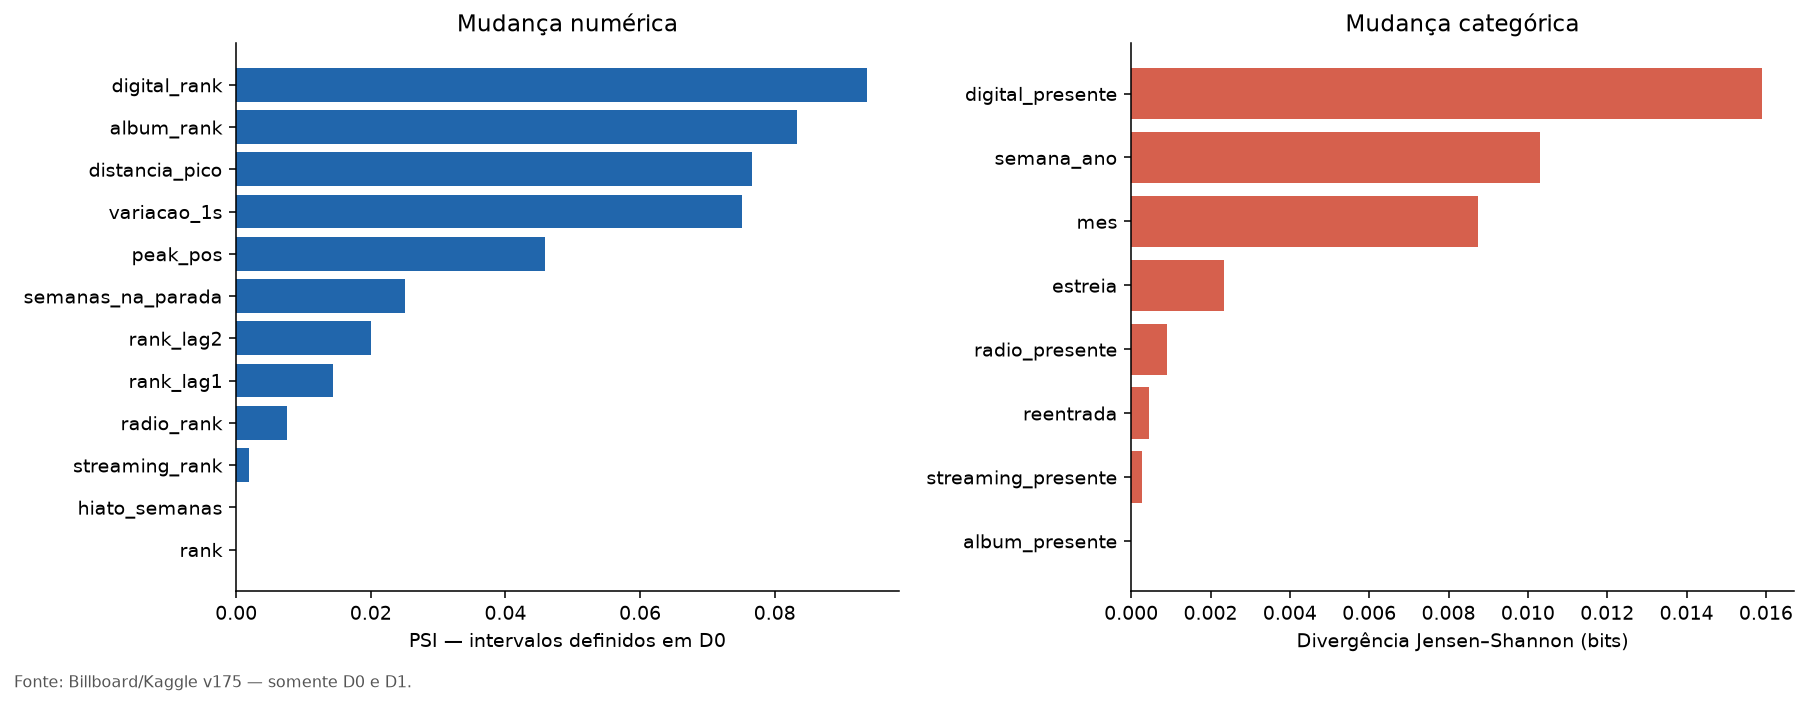

In [7]:
display(drift[drift.tipo == 'numerico'].sort_values('psi', ascending=False))
display(drift[drift.tipo != 'numerico'].sort_values('js_bits', ascending=False))
display(Image(filename='resultados/aed_drift/figuras/drift.png'))

## Conclusões e limites

A interpretação abaixo é gerada com os valores desta execução. Nenhum atributo é selecionado ou removido por esta análise. A decisão sobre atualização exige a comparação futura em D2.

In [8]:
display(Markdown(Path('resultados/aed_drift/RELATORIO.md').read_text(encoding='utf-8')))

# AED e E11 — Mudança de distribuição D0 → D1

Pergunta: os dados recentes diferem dos históricos? Dados: somente D0/D1,
verificados pelos hashes do manifesto. D2 não foi carregado.

D0: 42,800 linhas; D1: 14,200 linhas.
Proporção positiva: 0.3616 → 0.3130, variação de -4.86 pontos percentuais.

## Mudanças numéricas (ordenadas por PSI)

| Atributo | PSI | KS | Wasserstein / IQR de D0 |
|---|---:|---:|---:|
| digital_rank | 0.0937 | 0.1418 | 0.1437 |
| album_rank | 0.0833 | 0.0853 | 0.0267 |
| distancia_pico | 0.0766 | 0.1199 | 0.2910 |
| variacao_1s | 0.0752 | 0.0708 | 0.4833 |
| peak_pos | 0.0458 | 0.1029 | 0.1084 |

Maiores divergências categóricas: digital_presente (0.0159 bits), semana_ano (0.0103 bits), mes (0.0087 bits).

## Método e interpretação

KS mede a maior diferença entre distribuições acumuladas. PSI usa quantis
de D0 (até dez intervalos), caudas infinitas e pseudocontagem 0,5 por intervalo.
Wasserstein está nas unidades do atributo; sua razão pelo IQR de D0 é deixada
vazia quando o IQR é zero. Jensen–Shannon é a divergência em bits, não a distância.
PSI e JS não devem ser comparados na mesma escala. Não usamos limiares automáticos
para declarar drift nem p-valores iid: músicas se repetem e semanas são dependentes.

As diferenças medem mudança de distribuição dos atributos e do alvo. Não provam
mudança da relação condicional entre atributos e alvo (concept drift), nem causalidade.
Mudanças de cobertura dos rankings auxiliares também podem refletir a coleta.
Variáveis de calendário refletem sazonalidade e composição dos períodos.
Correlação entre posições e indicadores pode ser induzida pelas regras de construção.

## Ausências, censuras e passagens

Os atributos processados não têm nulos. Ausência no Hot 100 anterior usa posição
101; ranking secundário ausente usa 51; álbum ausente usa 201, acompanhado de
indicadores de presença. Esses valores são convenções, não posições observadas.
`estreia` indica início de uma passagem; inclui retorno após hiato superior a 28 dias.
`reentrada` identifica os inícios de passagem de música já observada. Portanto,
esses indicadores não representam necessariamente primeira estreia da carreira.

## Decisão e próximos passos

Há mudança mensurável entre D0 e D1, a ser relacionada ao desempenho de M0.
Manter a avaliação temporal e as quatro estratégias previstas; nenhuma variável
foi descartada com base nesta exploração. A avaliação futura exige protocolo
congelado. Artefatos quantitativos e seis figuras acompanham este relatório.
